# Variational Autoencoder (VAE) for MNIST
## Pure NumPy — No PyTorch or TensorFlow

This notebook implements a full VAE from scratch using only **NumPy** and the
Python standard library.  No automatic differentiation is used — every gradient
is derived analytically and computed explicitly.

**Contents**

| Section | Topic |
|:--------|:------|
| 1 | Theory: ELBO, reparameterisation, gradients |
| 2 | Activations, helpers, Adam optimiser |
| 3 | VAE class — forward pass |
| 4 | VAE class — backward pass (manual backprop) |
| 5 | VAE class — training loop |
| 6 | MNIST loading (pure Python, no framework) |
| 7 | Training |
| 8 | Reconstructions and generated samples |
| 9 | Latent space visualisation and interpolation |

## 1. Theory

### The generative model

A VAE posits a latent-variable model

$$p(\boldsymbol{x}) = \int p(\boldsymbol{x}|\boldsymbol{z})\,p(\boldsymbol{z})\,d\boldsymbol{z}$$

with a standard Gaussian prior $p(\boldsymbol{z}) = \mathcal{N}(\boldsymbol{0},\boldsymbol{I})$
and a Bernoulli decoder $p(\boldsymbol{x}|\boldsymbol{z}) = \prod_i \hat{x}_i^{x_i}(1-\hat{x}_i)^{1-x_i}$
for binary pixels.

### Evidence Lower BOund (ELBO)

Because the integral over $\boldsymbol{z}$ is intractable, we introduce an
approximate posterior $q(\boldsymbol{z}|\boldsymbol{x}) = \mathcal{N}(\boldsymbol{\mu}(\boldsymbol{x}),
\,\mathrm{diag}(\boldsymbol{\sigma}^2(\boldsymbol{x})))$ (the encoder) and maximise

$$\mathrm{ELBO} = \underbrace{\mathbb{E}_{q(\boldsymbol{z}|\boldsymbol{x})}\bigl[\log p(\boldsymbol{x}|\boldsymbol{z})\bigr]}_{\text{reconstruction}}
                - \underbrace{\mathrm{KL}\bigl(q(\boldsymbol{z}|\boldsymbol{x})\,\|\,p(\boldsymbol{z})\bigr)}_{\text{regularisation}}$$

In practice we minimise $\mathcal{L} = -\mathrm{ELBO} = \mathrm{BCE} + \mathrm{KL}$.

### Loss terms

**Binary cross-entropy** (reconstruction, summed over pixels, averaged over batch):

$$\mathrm{BCE} = -\sum_i\bigl[x_i\log\hat{x}_i + (1-x_i)\log(1-\hat{x}_i)\bigr]$$

**KL divergence** (closed form for Gaussian prior):

$$\mathrm{KL} = -\frac{1}{2}\sum_j\bigl[1 + \log\sigma^2_j - \mu^2_j - \sigma^2_j\bigr]$$

### Reparameterisation trick

Sampling $\boldsymbol{z} \sim q(\boldsymbol{z}|\boldsymbol{x})$ is non-differentiable.
We rewrite:

$$\boldsymbol{z} = \boldsymbol{\mu}(\boldsymbol{x}) + \boldsymbol{\sigma}(\boldsymbol{x}) \odot \boldsymbol{\varepsilon},
\qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\boldsymbol{0},\boldsymbol{I})$$

so $\boldsymbol{z}$ is a **deterministic function** of the parameters given $\boldsymbol{\varepsilon}$,
and gradients flow through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$.

### Key gradient identities

| Expression | Formula | Notes |
|:-----------|:--------|:------|
| $\partial\mathcal{L}/\partial s$ | $\hat{x} - x$ | $s$ = pre-sigmoid output; BCE+sigmoid cancels |
| $\partial\mathrm{KL}/\partial\boldsymbol{\mu}$ | $\boldsymbol{\mu}/B$ | Direct from KL formula |
| $\partial\mathrm{KL}/\partial\log\sigma^2$ | $\frac{1}{2}(\exp(\log\sigma^2)-1)/B$ | Direct from KL formula |
| $\partial\mathcal{L}/\partial\boldsymbol{\mu}_{\rm enc}$ | $\partial\mathcal{L}_{\rm dec}/\partial\boldsymbol{z} + \partial\mathrm{KL}/\partial\boldsymbol{\mu}$ | Chain rule through $z$ |
| $\partial\mathcal{L}/\partial\log\sigma^2$ | $\partial\mathcal{L}_{\rm dec}/\partial\boldsymbol{z}\cdot\frac{1}{2}\sigma\varepsilon + \partial\mathrm{KL}/\partial\log\sigma^2$ | Reparameterisation |

### Architecture

```
Encoder   x (784) → Dense(256)+ReLU → Dense(128)+ReLU → μ, logσ² (16 each)
Reparam   z = μ + exp(½ logσ²) ⊙ ε,   ε ~ N(0,I)
Decoder   z (16)  → Dense(128)+ReLU → Dense(256)+ReLU → Dense(784)+Sigmoid
```

---

## 2. Imports, Activations, and Adam Optimiser

In [1]:
%matplotlib inline
import gzip, math, os, struct, time, urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
SEP = '=' * 68


# ── Activation functions ──────────────────────────────────────────────

def sigmoid(z):
    """Numerically stable sigmoid  σ(z) = 1/(1+e^{-z})."""
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

def relu(z):
    """ReLU  f(z) = max(0, z)."""
    return np.maximum(0.0, z)

def relu_grad(z):
    """Derivative of ReLU: 1{z > 0}."""
    return (z > 0).astype(np.float32)

def he_init(fan_in, fan_out, rng_):
    """He (Kaiming) normal initialisation for ReLU nets."""
    return rng_.normal(0, np.sqrt(2.0/fan_in), (fan_in, fan_out)).astype(np.float32)


# ── Image grid display ────────────────────────────────────────────────

def show_grid(images, nrow=10, title='', figsize=(12, None)):
    imgs = np.asarray(images, dtype=np.float32)
    if imgs.ndim == 2 and imgs.shape[1] == 784:
        imgs = imgs.reshape(-1, 28, 28)
    N = len(imgs); nrows_fig = math.ceil(N / nrow)
    h = figsize[1] or nrows_fig * 1.5
    fig, axes = plt.subplots(nrows_fig, nrow, figsize=(figsize[0], h))
    for ax in np.array(axes).flatten(): ax.axis('off')
    for i, img in enumerate(imgs):
        np.array(axes).flatten()[i].imshow(
            img, cmap='gray_r', vmin=0, vmax=1, interpolation='nearest')
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


# ── Adam optimiser ────────────────────────────────────────────────────

class Adam:
    """
    Adam optimiser — pure NumPy.

    m_t = β₁ m_{t-1} + (1−β₁) g_t          first moment
    v_t = β₂ v_{t-1} + (1−β₂) g²_t         second moment
    θ_t = θ_{t-1} − α m̂_t / (√v̂_t + ε)   bias-corrected update
    """
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2
        self.eps = eps; self.t = 0; self.m = {}; self.v = {}

    def update(self, params, grads):
        self.t += 1
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t
        for name, g in grads.items():
            if name not in self.m:
                self.m[name] = np.zeros_like(params[name])
                self.v[name] = np.zeros_like(params[name])
            self.m[name] = self.beta1*self.m[name] + (1-self.beta1)*g
            self.v[name] = self.beta2*self.v[name] + (1-self.beta2)*g**2
            params[name] -= self.lr*(self.m[name]/bc1) / (np.sqrt(self.v[name]/bc2)+self.eps)
        return params

## 3. VAE Class — Forward Pass

All parameters are stored in `self.params` as a flat dict of `float32` NumPy
arrays.  Every intermediate activation is saved in `self.cache` during the
forward pass so the backward pass can reuse it without recomputation.

**Parameter shapes:**

| Name | Shape | Role |
|:-----|:------|:-----|
| `W_enc1`, `b_enc1` | $(784, 256)$, $(256,)$ | Encoder layer 1 |
| `W_enc2`, `b_enc2` | $(256, 128)$, $(128,)$ | Encoder layer 2 |
| `W_mu`, `b_mu` | $(128, Z)$, $(Z,)$ | Encoder → mean $\boldsymbol{\mu}$ |
| `W_lv`, `b_lv` | $(128, Z)$, $(Z,)$ | Encoder → log-variance $\log\sigma^2$ |
| `W_dec1`, `b_dec1` | $(Z, 128)$, $(128,)$ | Decoder layer 1 |
| `W_dec2`, `b_dec2` | $(128, 256)$, $(256,)$ | Decoder layer 2 |
| `W_out`, `b_out` | $(256, 784)$, $(784,)$ | Decoder output |

**He initialisation** is used for the hidden layers (recommended for ReLU nets):
$w \sim \mathcal{N}(0, 2/\text{fan\_in})$.

In [2]:
class VAE:
    """
    Variational Autoencoder — pure NumPy.

    Forward:  encode → reparameterise → decode → loss
    Backward: full manual backpropagation
    Training: Adam mini-batch SGD
    """

    def __init__(self, input_dim=784, hidden_enc=(256, 128),
                 latent_dim=16, hidden_dec=(128, 256), rng_=None):
        if rng_ is None:
            rng_ = np.random.default_rng(42)
        self.D = input_dim; self.Z = latent_dim
        self.h_enc = hidden_enc; self.h_dec = hidden_dec
        self.cache = {}
        p = {}

        # Encoder hidden layers
        in_d = input_dim
        for k, h in enumerate(hidden_enc):
            p[f"W_enc{k+1}"] = he_init(in_d, h, rng_)
            p[f"b_enc{k+1}"] = np.zeros(h, dtype=np.float32)
            in_d = h

        # Encoder outputs: mu and log-variance
        p["W_mu"] = rng_.normal(0, 0.01, (in_d, latent_dim)).astype(np.float32)
        p["b_mu"] = np.zeros(latent_dim, dtype=np.float32)
        p["W_lv"] = rng_.normal(0, 0.01, (in_d, latent_dim)).astype(np.float32)
        p["b_lv"] = np.zeros(latent_dim, dtype=np.float32)

        # Decoder hidden layers
        in_d = latent_dim
        for k, h in enumerate(hidden_dec):
            p[f"W_dec{k+1}"] = he_init(in_d, h, rng_)
            p[f"b_dec{k+1}"] = np.zeros(h, dtype=np.float32)
            in_d = h

        # Decoder output
        p["W_out"] = rng_.normal(0, 0.01, (in_d, input_dim)).astype(np.float32)
        p["b_out"] = np.zeros(input_dim, dtype=np.float32)

        self.params = p
        n_p = sum(v.size for v in p.values())
        print(f"VAE: 784→{hidden_enc}→({latent_dim}μ,{latent_dim}logσ²)→{hidden_dec}→784")
        print(f"Parameters: {n_p:,}")

    # ── Encoder ────────────────────────────────────────────────────────

    def encode(self, x):
        """
        x : (B, 784)  →  mu, logvar : (B, Z) each.
        Caches all pre-activations for backward().
        """
        p, c = self.params, self.cache
        c["x"]        = x
        c["pre_enc1"] = x           @ p["W_enc1"] + p["b_enc1"]
        c["h_enc1"]   = relu(c["pre_enc1"])
        c["pre_enc2"] = c["h_enc1"] @ p["W_enc2"] + p["b_enc2"]
        c["h_enc2"]   = relu(c["pre_enc2"])
        c["mu"]       = c["h_enc2"] @ p["W_mu"]   + p["b_mu"]
        c["logvar"]   = c["h_enc2"] @ p["W_lv"]   + p["b_lv"]
        return c["mu"], c["logvar"]

    # ── Reparameterisation ─────────────────────────────────────────────

    def reparameterise(self, mu, logvar):
        """
        z = μ + σ ⊙ ε,   σ = exp(½ logvar),   ε ~ N(0,I).
        Caches ε and σ for use in backward().
        """
        c = self.cache
        eps        = rng.standard_normal(mu.shape).astype(np.float32)
        sigma      = np.exp(0.5 * logvar)
        c["eps"]   = eps
        c["sigma"] = sigma
        c["z"]     = mu + sigma * eps
        return c["z"]

    # ── Decoder ────────────────────────────────────────────────────────

    def decode(self, z):
        """
        z : (B, Z)  →  x_hat : (B, 784), pixel probs in (0, 1).
        Caches decoder pre-activations for backward().
        """
        p, c = self.params, self.cache
        c["z"]        = z
        c["pre_dec1"] = z           @ p["W_dec1"] + p["b_dec1"]
        c["h_dec1"]   = relu(c["pre_dec1"])
        c["pre_dec2"] = c["h_dec1"] @ p["W_dec2"] + p["b_dec2"]
        c["h_dec2"]   = relu(c["pre_dec2"])
        c["pre_out"]  = c["h_dec2"] @ p["W_out"]  + p["b_out"]
        c["x_hat"]    = sigmoid(c["pre_out"])
        return c["x_hat"]

    # ── Loss ───────────────────────────────────────────────────────────

    def loss(self, x, x_hat, mu, logvar):
        """
        BCE  = −Σ [x log x̂ + (1−x) log(1−x̂)]   sum over pixels, mean over batch
        KL   = −½ Σ [1 + logvar − μ² − exp(logvar)]   sum over Z, mean over batch
        Returns (total, bce, kl) — scalar floats.
        """
        eps_n = 1e-8
        bce = -np.sum(x*np.log(x_hat+eps_n) + (1-x)*np.log(1-x_hat+eps_n), axis=1)
        kl  = -0.5*np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1)
        return float(np.mean(bce+kl)), float(np.mean(bce)), float(np.mean(kl))

    # ── Full forward ───────────────────────────────────────────────────

    def forward(self, x):
        """encode → reparameterise → decode → loss."""
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        x_hat      = self.decode(z)
        losses     = self.loss(x, x_hat, mu, logvar)
        return x_hat, mu, logvar, losses

    # ── Backward (manual backpropagation) ──────────────────────────────

    def backward(self, x):
        """
        Gradients of L = mean_B[BCE + KL] w.r.t. all parameters.
        Must be called after forward(x) — reuses self.cache.

        Key identities
        (A) ∂L/∂pre_out = (x̂ − x)/B       BCE + sigmoid cancels
        (B) ∂KL/∂μ = μ/B,  ∂KL/∂logvar = ½(exp(logvar)−1)/B
        (C) ∂L/∂μ_enc = ∂L_dec/∂z + ∂KL/∂μ
            ∂L/∂logvar = ∂L_dec/∂z · ½σε + ∂KL/∂logvar
        """
        p, c  = self.params, self.cache
        B     = x.shape[0]
        grads = {}

        # (A) Decoder output
        d_pre_out      = (c["x_hat"] - x) / B         # (B, 784)
        grads["W_out"] = c["h_dec2"].T @ d_pre_out    # (256, 784)
        grads["b_out"] = d_pre_out.sum(axis=0)        # (784,)
        d_h_dec2       = d_pre_out @ p["W_out"].T     # (B, 256)

        # Decoder hidden layer 2
        d_pre_dec2      = d_h_dec2 * relu_grad(c["pre_dec2"])  # (B, 256)
        grads["W_dec2"] = c["h_dec1"].T @ d_pre_dec2           # (128, 256)
        grads["b_dec2"] = d_pre_dec2.sum(axis=0)               # (256,)
        d_h_dec1        = d_pre_dec2 @ p["W_dec2"].T           # (B, 128)

        # Decoder hidden layer 1
        d_pre_dec1      = d_h_dec1 * relu_grad(c["pre_dec1"])  # (B, 128)
        grads["W_dec1"] = c["z"].T @ d_pre_dec1                # (Z, 128)
        grads["b_dec1"] = d_pre_dec1.sum(axis=0)               # (128,)
        d_z             = d_pre_dec1 @ p["W_dec1"].T           # (B, Z)

        # (B) KL gradients
        d_kl_mu     = c["mu"] / B                              # (B, Z)
        d_kl_logvar = 0.5 * (np.exp(c["logvar"]) - 1.0) / B   # (B, Z)

        # (C) Reparameterisation chain rule
        d_mu     = d_z + d_kl_mu                               # (B, Z)
        d_logvar = d_z * (0.5*c["sigma"]*c["eps"]) + d_kl_logvar  # (B, Z)

        # Encoder output layers
        grads["W_mu"]  = c["h_enc2"].T @ d_mu                  # (128, Z)
        grads["b_mu"]  = d_mu.sum(axis=0)                      # (Z,)
        grads["W_lv"]  = c["h_enc2"].T @ d_logvar              # (128, Z)
        grads["b_lv"]  = d_logvar.sum(axis=0)                  # (Z,)
        d_h_enc2 = d_mu @ p["W_mu"].T + d_logvar @ p["W_lv"].T  # (B, 128)

        # Encoder hidden layer 2
        d_pre_enc2      = d_h_enc2 * relu_grad(c["pre_enc2"])  # (B, 128)
        grads["W_enc2"] = c["h_enc1"].T @ d_pre_enc2           # (256, 128)
        grads["b_enc2"] = d_pre_enc2.sum(axis=0)               # (128,)
        d_h_enc1        = d_pre_enc2 @ p["W_enc2"].T           # (B, 256)

        # Encoder hidden layer 1
        d_pre_enc1      = d_h_enc1 * relu_grad(c["pre_enc1"])  # (B, 256)
        grads["W_enc1"] = x.T @ d_pre_enc1                     # (784, 256)
        grads["b_enc1"] = d_pre_enc1.sum(axis=0)               # (256,)
        return grads

    # ── Training loop ──────────────────────────────────────────────────

    def train(self, X_train, X_val=None,
              epochs=30, batch_size=128, lr=1e-3, verbose=True):
        """
        Mini-batch Adam training.

        Parameters
        ----------
        X_train    : (N, 784) float32 in [0, 1]
        X_val      : optional (M, 784) for monitoring
        epochs     : full passes over training data
        batch_size : mini-batch size
        lr         : Adam learning rate
        verbose    : print per-epoch summary

        Returns history dict:
            train_loss, train_bce, train_kl, val_loss (if X_val given)
        """
        opt     = Adam(lr=lr)
        n       = len(X_train)
        history = {"train_loss": [], "train_bce": [], "train_kl": []}
        if X_val is not None:
            history["val_loss"] = []
        t0 = time.time()

        for ep in range(1, epochs + 1):
            t_ep = time.time()
            idx  = rng.permutation(n)
            ep_loss = ep_bce = ep_kl = 0.0
            n_batches = 0

            for s in range(0, n, batch_size):
                xb = X_train[idx[s:s + batch_size]]
                _, mu, logvar, (loss, bce, kl) = self.forward(xb)
                grads = self.backward(xb)
                opt.update(self.params, grads)
                ep_loss += loss; ep_bce += bce; ep_kl += kl
                n_batches += 1

            ep_loss /= n_batches; ep_bce /= n_batches; ep_kl /= n_batches
            history["train_loss"].append(ep_loss)
            history["train_bce"].append(ep_bce)
            history["train_kl"].append(ep_kl)

            val_str = ""
            if X_val is not None:
                v_losses = [
                    self.forward(X_val[s:s + batch_size])[3][0]
                    for s in range(0, len(X_val), batch_size)
                ]
                vl_mean = float(np.mean(v_losses))
                history["val_loss"].append(vl_mean)
                val_str = f"  val={vl_mean:.2f}"

            if verbose:
                print(f"  Epoch {ep:3d}/{epochs}"
                      f"  loss={ep_loss:.2f}  bce={ep_bce:.2f}"
                      f"  kl={ep_kl:.2f}{val_str}"
                      f"  ({time.time()-t_ep:.1f}s)")

        history["wall_s"] = time.time() - t0
        return history


# ── Sanity check: all methods present, gradient shapes correct ─────────────
_vae = VAE(input_dim=784, hidden_enc=(256, 128), latent_dim=16,
           hidden_dec=(128, 256), rng_=np.random.default_rng(0))
_x = np.random.rand(4, 784).astype(np.float32)
_vae.forward(_x)
_g = _vae.backward(_x)
methods_ok = all(hasattr(_vae, m) for m in
                 ("encode","decode","reparameterise","loss","forward","backward","train"))
shapes_ok  = all(_g[k].shape == _vae.params[k].shape for k in _g)
print(f"All methods present: {methods_ok}")
print(f"Gradient shapes OK : {shapes_ok}")
if not methods_ok or not shapes_ok:
    raise RuntimeError("VAE sanity check failed!")


VAE: 784→(256, 128)→(16μ,16logσ²)→(128, 256)→784
Parameters: 474,672
All methods present: True
Gradient shapes OK : True


## 4. VAE Class — Backward Pass (Manual Backpropagation)

Every gradient is derived analytically.  The computation follows the chain
rule from output back to input:

```
x̂ → pre_out → h_dec2 → pre_dec2 → h_dec1 → pre_dec1 → z
                                                          ↓
                                              μ,σ (reparameterisation)
                                                          ↓
                                              h_enc2 → h_enc1 → x
```

**Step 1: decoder output** (identity $\partial\mathcal{L}/\partial s = \hat{x} - x$)

The binary cross-entropy gradient w.r.t. $\hat{x}$ is
$\frac{\hat{x}-x}{\hat{x}(1-\hat{x})}$, and the sigmoid derivative is
$\hat{x}(1-\hat{x})$. These cancel exactly:

$$\frac{\partial\mathcal{L}}{\partial s_i}
= \frac{\partial\mathrm{BCE}}{\partial\hat{x}_i}\cdot
  \frac{\partial\hat{x}_i}{\partial s_i}
= \frac{\hat{x}_i-x_i}{\hat{x}_i(1-\hat{x}_i)}\cdot\hat{x}_i(1-\hat{x}_i)
= \hat{x}_i - x_i$$

**Step 2: KL gradients** (closed form)

$$\frac{\partial\mathrm{KL}}{\partial\mu_j} = \frac{\mu_j}{B}, \qquad
\frac{\partial\mathrm{KL}}{\partial\log\sigma^2_j}
= \frac{1}{2}\left(\exp(\log\sigma^2_j) - 1\right)\big/B$$

**Step 3: reparameterisation** (chain rule through $z = \mu + \sigma\varepsilon$)

$$\frac{\partial\mathcal{L}}{\partial\mu}
= \frac{\partial\mathcal{L}_{\rm dec}}{\partial z}\cdot 1
  + \frac{\partial\mathrm{KL}}{\partial\mu}, \qquad
\frac{\partial\mathcal{L}}{\partial\log\sigma^2}
= \frac{\partial\mathcal{L}_{\rm dec}}{\partial z}\cdot\frac{\sigma\varepsilon}{2}
  + \frac{\partial\mathrm{KL}}{\partial\log\sigma^2}$$

## 5. VAE Class — Training Loop

Mini-batch stochastic gradient descent with Adam.
Each epoch: shuffle → iterate over batches → forward → backward → Adam update.

## 6. MNIST Loading — Pure Python Standard Library

MNIST is stored as a simple binary format: a 16-byte header (magic number,
count, rows, cols) followed by raw `uint8` pixel bytes.  We download the
four gzipped files with `urllib`, parse them with `struct` and `gzip`,
and convert to `float32` NumPy arrays — no framework required.

A `torchvision` fallback is included if direct download fails (e.g., firewall).

Train: (55000, 784)   Val: (5000, 784)   Test: (10000, 784)


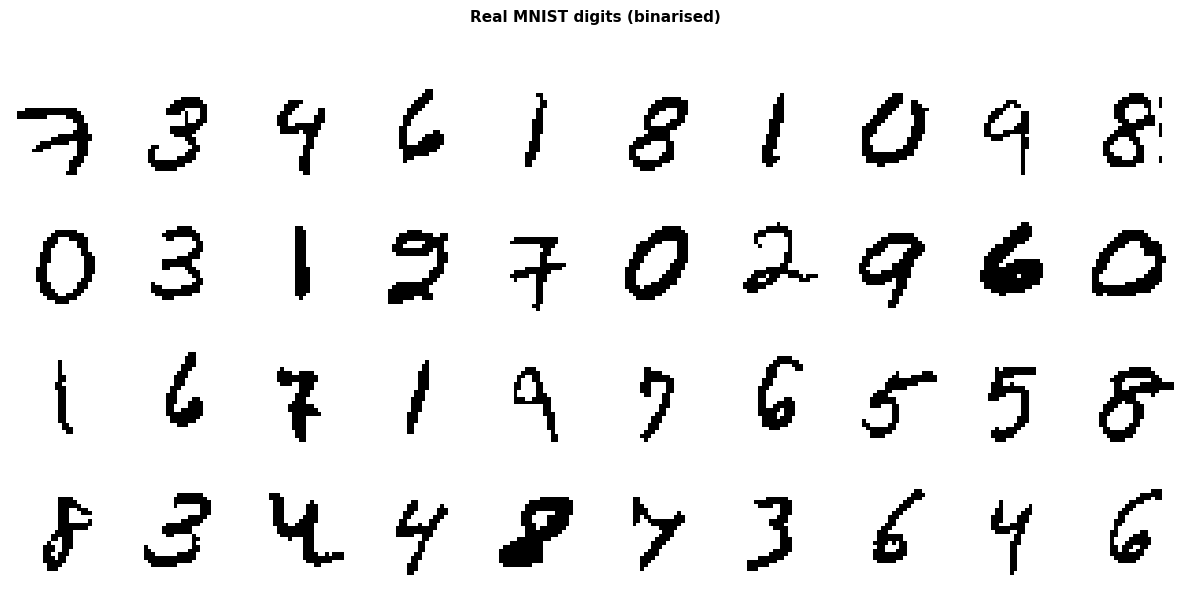

In [3]:
MNIST_URL   = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
MNIST_FILES = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images':  't10k-images-idx3-ubyte.gz',
    'test_labels':  't10k-labels-idx1-ubyte.gz',
}

def _download(data_dir='./data/mnist'):
    d = Path(data_dir); d.mkdir(parents=True, exist_ok=True)
    for name, fname in MNIST_FILES.items():
        fp = d / fname
        if not fp.exists():
            print(f'  Downloading {fname} ...', end=' ', flush=True)
            try:
                urllib.request.urlretrieve(MNIST_URL + fname, fp)
                print('done')
            except Exception as e:
                print(f'FAILED ({e})')

def _load_images(path):
    with gzip.open(path,'rb') as f:
        _, n, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows*cols).astype(np.float32) / 255.0

def _load_labels(path):
    with gzip.open(path,'rb') as f:
        struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

def load_mnist(data_dir='./data/mnist', binarise=True, threshold=0.5):
    """
    Download and load MNIST.  Returns (X_train,y_train,X_test,y_test).
    Pixels optionally binarised to {0,1} at threshold 0.5.
    """
    _download(data_dir); d = Path(data_dir)
    try:
        X_tr = _load_images(d / MNIST_FILES['train_images'])
        y_tr = _load_labels(d / MNIST_FILES['train_labels'])
        X_te = _load_images(d / MNIST_FILES['test_images'])
        y_te = _load_labels(d / MNIST_FILES['test_labels'])
    except Exception as e:
        print(f'Direct load failed ({e}); using torchvision ...')
        from torchvision import datasets, transforms
        tf = transforms.ToTensor()
        def _tv(split):
            ds = datasets.MNIST('./data', train=split, download=True, transform=tf)
            X  = np.stack([x.numpy().flatten() for x,_ in ds]).astype(np.float32)
            y  = np.array([lab for _,lab in ds], dtype=np.uint8)
            return X, y
        X_tr,y_tr = _tv(True); X_te,y_te = _tv(False)
    if binarise:
        X_tr = (X_tr > threshold).astype(np.float32)
        X_te = (X_te > threshold).astype(np.float32)
    return X_tr, y_tr, X_te, y_te


X_train, y_train, X_test, y_test = load_mnist(binarise=True)
n_val   = 5000
X_val   = X_train[:n_val]; y_val   = y_train[:n_val]
X_train = X_train[n_val:]; y_train = y_train[n_val:]
print(f'Train: {X_train.shape}   Val: {X_val.shape}   Test: {X_test.shape}')
show_grid(X_train[:40], nrow=10, title='Real MNIST digits (binarised)')

## 7. Training

**Hyperparameters:**

| Setting | Value | Rationale |
|:--------|:------|:----------|
| `latent_dim` | 16 | Enough capacity; use 2 for direct 2D visualisation |
| `epochs` | 30 | Loss converges visibly; more epochs improve generation |
| `batch_size` | 128 | Standard for MNIST |
| `lr` | $10^{-3}$ | Default Adam learning rate |

> **Tip:** set `latent_dim=2` to get a direct 2D latent space scatter plot.
> The reconstruction quality will be slightly lower.

In [ ]:
LATENT_DIM = 16
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3

vae = VAE(input_dim=784, hidden_enc=(256,128),
           latent_dim=LATENT_DIM, hidden_dec=(128,256), rng_=rng)

print(f'latent_dim={LATENT_DIM},  epochs={EPOCHS},'
      f'  batch={BATCH_SIZE},  lr={LR}\n')

history = vae.train(X_train, X_val, epochs=EPOCHS,
                     batch_size=BATCH_SIZE, lr=LR, verbose=True)
print(f'\nTotal time: {history["wall_s"]:.1f}s')

VAE: 784→(256, 128)→(16μ,16logσ²)→(128, 256)→784
Parameters: 474,672
latent_dim=16,  epochs=30,  batch=128,  lr=0.001

  Epoch   1/30  loss=169.82  bce=159.96  kl=9.86  val=129.90  (129.5s)
  Epoch   2/30  loss=119.70  bce=100.76  kl=18.94  val=109.92  (188.3s)
  Epoch   3/30  loss=106.49  bce=84.98  kl=21.50  val=102.24  (91.0s)
  Epoch   4/30  loss=100.85  bce=78.43  kl=22.42  val=98.31  (185.9s)
  Epoch   5/30  loss=97.48  bce=74.37  kl=23.11  val=95.59  (148.5s)
  Epoch   6/30  loss=95.20  bce=71.53  kl=23.67  val=93.58  (187.5s)
  Epoch   7/30  loss=93.45  bce=69.31  kl=24.14  val=92.41  (134.9s)
  Epoch   8/30  loss=92.03  bce=67.56  kl=24.47  val=91.51  (101.6s)
  Epoch   9/30  loss=90.96  bce=66.19  kl=24.77  val=90.29  (114.8s)
  Epoch  10/30  loss=90.05  bce=65.06  kl=24.99  val=89.85  (154.3s)
  Epoch  11/30  loss=89.32  bce=64.15  kl=25.17  val=89.58  (85.5s)
  Epoch  12/30  loss=88.52  bce=63.22  kl=25.30  val=88.41  (137.1s)
  Epoch  13/30  loss=87.95  bce=62.49  kl=25.46

/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_28486/131600058.py:16: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + np.exp(-z)),


  Epoch  24/30  loss=84.15  bce=57.86  kl=26.28  val=86.16  (124.3s)


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ep = range(1, EPOCHS+1)
axes[0].plot(ep, history['train_loss'], 'b-', lw=2, label='Train')
if 'val_loss' in history:
    axes[0].plot(ep, history['val_loss'], 'r--', lw=1.5, label='Val')
    axes[0].legend()
axes[0].set(xlabel='Epoch', ylabel='ELBO loss', title='Total Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(ep, history['train_bce'], 'steelblue', lw=2)
axes[1].set(xlabel='Epoch', ylabel='BCE', title='Reconstruction')
axes[1].grid(True, alpha=0.3)
axes[2].plot(ep, history['train_kl'], 'firebrick', lw=2)
axes[2].set(xlabel='Epoch', ylabel='KL', title='KL Divergence')
axes[2].grid(True, alpha=0.3)
fig.suptitle('VAE Training (Pure NumPy)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Reconstructions and Generated Samples

**Reconstructions:** encode a test image → sample $z$ → decode.

**Generation:** sample $z \sim \mathcal{N}(\boldsymbol{0},\boldsymbol{I})$ directly, then decode.
This is pure sampling from the learned prior — no input image is used.

In [ ]:
# Reconstructions
x_sample = X_test[:80]
x_hat, _, _, _ = vae.forward(x_sample)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for ax in axes.flatten(): ax.axis('off')
for i in range(10):
    axes[0,i].imshow(x_sample[i].reshape(28,28), cmap='gray_r', vmin=0,vmax=1)
    axes[1,i].imshow(x_hat[i].reshape(28,28),    cmap='gray_r', vmin=0,vmax=1)
axes[0,0].set_ylabel('Input',  fontsize=9)
axes[1,0].set_ylabel('Recon.', fontsize=9)
fig.suptitle('Top: binarised test images  |  Bottom: VAE reconstructions',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

# Per-class MSE
print('Reconstruction MSE per digit class:')
print(f'  {"Digit":>6s}  {"MSE":>8s}  {"N":>6s}'); print('  '+'-'*24)
for d in range(10):
    mask = (y_test==d); Xd = X_test[mask]
    Xd_hat,_,_,_ = vae.forward(Xd)
    mse = float(np.mean((Xd-Xd_hat)**2))
    print(f'  {d:>6d}  {mse:>8.5f}  {mask.sum():>6d}')

In [ ]:
# Generate new samples from z ~ N(0,I)
z_random = rng.standard_normal((80, LATENT_DIM)).astype(np.float32)
x_gen    = vae.decode(z_random)
show_grid(x_gen, nrow=10,
          title=f'Generated MNIST digits  —  z ~ N(0,I),  latent_dim={LATENT_DIM}')

## 9. Latent Space Visualisation and Interpolation

### PCA projection of the latent space

We encode the full test set to get the means $\boldsymbol{\mu}(\boldsymbol{x})$,
then project to 2D using PCA (computed with `np.linalg.svd`).
A well-trained VAE shows digit classes clustered in distinct regions.

### Latent-space interpolation

For two digits $d_1$ and $d_2$, we encode one example of each to get
$\boldsymbol{\mu}_1$ and $\boldsymbol{\mu}_2$, then decode the linear path
$\boldsymbol{z}(t) = (1-t)\boldsymbol{\mu}_1 + t\boldsymbol{\mu}_2$ for
$t \in [0,1]$. A smooth interpolation is a sign of a well-organised
latent space.

### Latent manifold

We sweep $z_1$ and $z_2$ over $[-2.5, 2.5]$ (fixing all other latent
dimensions to 0) and decode each grid point, visualising the learned
2D slice of the latent manifold.

In [ ]:
# Encode test set → latent means
mu_all = np.zeros((len(X_test), LATENT_DIM), dtype=np.float32)
for s in range(0, len(X_test), 256):
    mu_all[s:s+256], _ = vae.encode(X_test[s:s+256])

if LATENT_DIM == 2:
    fig, ax = plt.subplots(figsize=(8,7))
    sc = ax.scatter(mu_all[:,0], mu_all[:,1], c=y_test, cmap='tab10', s=4, alpha=0.5)
    plt.colorbar(sc, ax=ax, label='Digit class')
    ax.set(xlabel='z₁', ylabel='z₂', title='Latent space μ (2D)')
    plt.tight_layout(); plt.show()
else:
    # PCA to 2D — pure NumPy
    mu_c = mu_all - mu_all.mean(axis=0)
    _, S, Vt = np.linalg.svd(mu_c, full_matrices=False)
    mu_2d  = mu_c @ Vt[:2].T
    var_ex = S[:2]**2 / np.sum(S**2) * 100
    fig, ax = plt.subplots(figsize=(8,7))
    sc = ax.scatter(mu_2d[:,0], mu_2d[:,1], c=y_test, cmap='tab10', s=4, alpha=0.5)
    plt.colorbar(sc, ax=ax, label='Digit class')
    ax.set(xlabel=f'PC1 ({var_ex[0]:.1f}%)', ylabel=f'PC2 ({var_ex[1]:.1f}%)',
           title=f'Latent space — PCA  (latent_dim={LATENT_DIM})')
    plt.tight_layout(); plt.show()

In [ ]:
# Latent-space interpolation between digit pairs
pairs   = [(0, 1), (3, 8), (4, 9)]
n_steps = 10
fig, axes = plt.subplots(len(pairs), n_steps, figsize=(14, len(pairs)*1.6))
for row, (d1, d2) in enumerate(pairs):
    x1 = X_test[y_test==d1][[0]]; x2 = X_test[y_test==d2][[0]]
    mu1,_ = vae.encode(x1);       mu2,_ = vae.encode(x2)
    for col, t in enumerate(np.linspace(0,1,n_steps)):
        z_int = ((1-t)*mu1 + t*mu2).astype(np.float32)
        img   = vae.decode(z_int)[0].reshape(28,28)
        axes[row,col].imshow(img, cmap='gray_r', vmin=0, vmax=1)
        axes[row,col].axis('off')
    axes[row,0].set_ylabel(f'{d1}→{d2}', fontsize=8, rotation=0,
                            labelpad=24, va='center')
fig.suptitle('Latent-space interpolation between digit classes',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Latent manifold: sweep z₁ and z₂, fix rest at 0
n_grid = 15
z_vals = np.linspace(-2.5, 2.5, n_grid)
fig, axes = plt.subplots(n_grid, n_grid, figsize=(12,12))
for axes_row in axes:
    for ax in axes_row: ax.axis('off')
for i, zi in enumerate(z_vals):
    for j, zj in enumerate(z_vals):
        z_pt = np.zeros((1, LATENT_DIM), dtype=np.float32)
        z_pt[0,0] = zi; z_pt[0,1] = zj
        img = vae.decode(z_pt)[0].reshape(28,28)
        axes[i,j].imshow(img, cmap='gray_r', vmin=0, vmax=1)
fig.suptitle(
    f'Latent manifold: z₁ ∈ [−2.5, 2.5] × z₂ ∈ [−2.5, 2.5]'
    f'\n(remaining {LATENT_DIM-2} dims fixed at 0)',
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

| Component | Implementation |
|:----------|:--------------|
| **Encoder** | Two ReLU dense layers + two output heads (μ and logσ²) |
| **Reparameterisation** | $z = \mu + \sigma\varepsilon$, $\varepsilon\sim\mathcal{N}(0,I)$ — NumPy only |
| **Decoder** | Two ReLU dense layers + sigmoid output |
| **Loss** | BCE + KL, both summed over dims, averaged over batch |
| **Backward** | Full manual chain rule — no autograd |
| **Optimiser** | Adam with bias-corrected moment estimates |
| **Data loading** | `urllib` + `gzip` + `struct` — no framework |

**Three ways to generate new digits:**

1. **Pure generation:** sample $\boldsymbol{z}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$,
   decode → pixel probabilities
2. **Interpolation:** encode two images → linear path between $\boldsymbol{\mu}_1$
   and $\boldsymbol{\mu}_2$ → decode
3. **Manifold sweep:** hold all but two latent dims fixed, sweep those two
   over a grid → decode